# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Matthew Calvario

**Date:** 09/09/26

In [ ]:
# Your Phase 1 solution to the problem goes here.


**Question 1.**

**Q1.1:**
m(a + bX) = m(a) + m(bX), the mean of a constant is always the constant itself; thus:

a + m(bX), similarly, the multiplicaiton of a constant and variable is linear, so you can separate m(b) and m(X):

a + m(b)m(X) = **a + b x m(X)**

**Q1.2-4:**
I will upload the rest of the solutions to my Github Repository.


In [3]:
!git clone https://github.com/Matthew-Calvario/A02-eda-and-visualization.git

Cloning into 'A02-eda-and-visualization'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 19 (delta 1), reused 0 (delta 0), pack-reused 14 (from 1)
Receiving objects: 100% (19/19), 1.32 MiB | 13.48 MiB/s, done.
Resolving deltas: 100% (3/3), done.


(28221,)


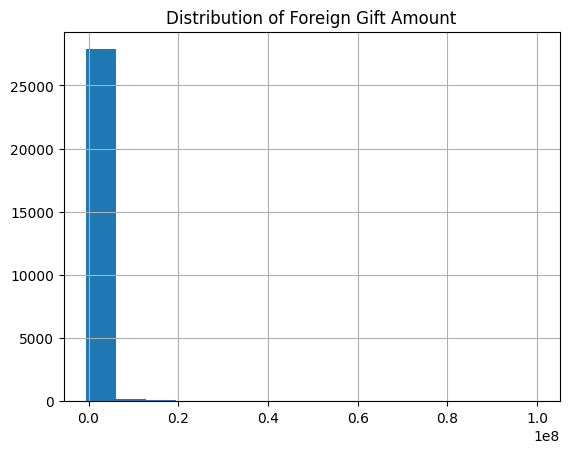

Total gifts: 28221
       Gift Type  count
0       Contract  17274
1  Monetary Gift  10936
2    Real Estate     11
The proportion of Contract gifts to total gifts is 0.6120973742957372.
The proportion of Contract gifts to total gifts is 0.3875128450444704.
The proportion of Contract gifts to total gifts is 0.00038978065979235324.


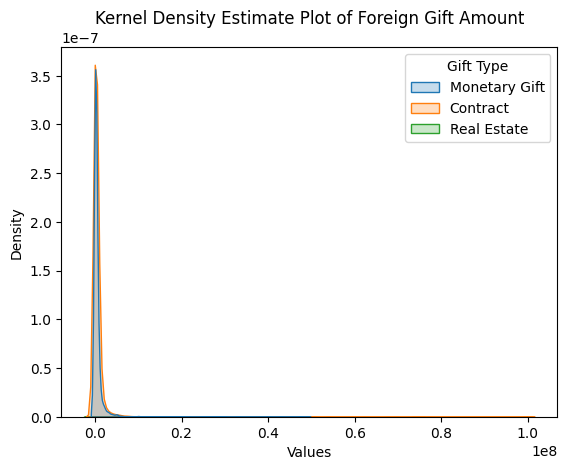

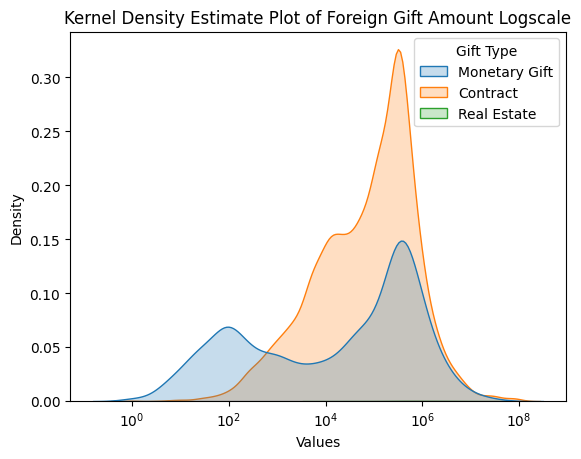

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64
Giftor Name
Qatar Foundati

In [66]:
# Question 2

# Q2.1

import numpy as np
import pandas as pd
import matplotlib as plt

df = pd.read_csv('A02-eda-and-visualization/data/ForeignGifts_edu.csv',)

# Q2.2

import matplotlib.pyplot as plt

print(df['Foreign Gift Amount'].shape)

df.hist(column=['Foreign Gift Amount'], bins=15)
plt.title('Distribution of Foreign Gift Amount')
plt.show()

# Findings: After plotting the histogram for "Foreign Gift Amount", it appears that
# the graph is extremely right skewed, with the vasy majority of gifts ranging in the lower
# range of price but a miniscule amount of the samples reaching costs far beyond the average.
# Thus, these rare but extremely large foreign gift amounts may impact calculations substantially
# impact statistics such as the range and the mean.

# Q2.3

total_gift_type = len(df['Gift Type'].index)
print(f'Total gifts: {total_gift_type}')
counts_df = df['Gift Type'].value_counts().reset_index()
print(counts_df)

print(f'The proportion of Contract gifts to total gifts is {(17274)/ (total_gift_type)}.')
print(f'The proportion of Contract gifts to total gifts is {(10936)/ (total_gift_type)}.')
print(f'The proportion of Contract gifts to total gifts is {(11)/ (total_gift_type)}.')

# Q2.4

import seaborn as sns

# Original

sns.kdeplot(df, x='Foreign Gift Amount', fill=True, color="blue", hue = 'Gift Type')


plt.title("Kernel Density Estimate Plot of Foreign Gift Amount")
plt.xlabel("Values")
plt.ylabel("Density")
plt.show()

# Logscale
sns.kdeplot(df, x='Foreign Gift Amount', log_scale = True, fill=True, color="blue", hue = 'Gift Type')

plt.title("Kernel Density Estimate Plot of Foreign Gift Amount Logscale")
plt.xlabel("Values")
plt.ylabel("Density")
plt.show()

# Based on the kernel density plots:
# - Contract gifts are more concentrated around a relatively high log gift amount as shown by the tall, orange peak
# - Monetary gifts also have many samples that coincide with contract gifts in the relatively high log gift amount, but is more evenly spread out
# and variable across the board (i.e. some concentration in lower ends and some in the higher ends; not as peaky as contract gifts)
# - Real estate is practically non existent in the log graph; they may be the values associated with the extreme large samples found earlier

# Q2.5

# Top 15 by number of gifts
print(df.groupby('Country of Giftor').size().sort_values(ascending=False).head(15)
)
# top 15 by amount given

print(df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
)
#Q2.6

# total Gift Money
print(df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15))

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 7dd4a84c6d4000c0dd9d7e6b0fd65c2b78c62d14
- **AI tool and model used:** Claude Sonnet 5

### *Prompts used

1. Can you double check my work for Question 1 and Question 2? Go through each part and tell me if anything is wrong, unclear, or could be improved. Try to keep changes minimal if my work is already correct. Also explain why you would make each change and how I could check that the change is actually correct.
2. Could you verify/improve the conclusions I drew from the graphics I created, including the new kernel density plot (or if any of the questions required some sort of interpretation); I would also like to know if there are any other inefficiencies in logic that could be addressed. If not, do not raise issue



### *AI-proposed changes


Q1 (proofs)

1. Q1.1 — Correct as written in the notebook.

2. Q1.2 — Final result and overall chain (steps 1, 3, 4, 5) are correct: substituting m(a+bY) = a + b·m(Y) from Q1.1, then factoring out b, gives b·cov(X,Y). One line (the second one in your PDF) reads as a garbled mix of the step before and after it — likely a PDF/handwriting-extraction artifact rather than an actual math error, since the lines around it are clean. Worth glancing at your original page to confirm that line reads cleanly. Check it: plug in a tiny numeric example (e.g., X=[1,2,3], Y=[1,2,3], a=1, b=2) and confirm cov(X,a+bY) = b·cov(X,Y) numerically.

3. Q1.3 — Correct throughout, and nice touch explicitly showing that dropping b² reduces to s² = cov(X,X).

4. Q1.4 — Correct answer and correct counterexample (g(x)=x², X=[1,3]: m(g(X))=5, g(m(X))=4). One sentence trails off — "...since the space between different values." Finish that thought, e.g. "...since a nonlinear transformation stretches/compresses parts of the range unevenly, so averaging before vs. after transforming isn't the same."

Q2 (code)

5. Q2.3 — copy/paste label bug. All three print statements say "Contract gifts" but the numbers (17274, 10936, 11) are presumably Contract, Monetary, and Real Estate. Fix the text on lines 2 and 3. Check: compare each hardcoded number against the corresponding row in counts_df.

6. Q2.3 — hardcoded proportions are fragile. If the CSV changes, these numbers go stale silently. More robust: df['Gift Type'].value_counts(normalize=True) gives you the proportions directly, or reference counts_df instead of typing numbers in. Check: confirm the normalized value_counts output matches your manual division.

7. Q2.3 — worth verifying. Confirm 17274 + 10936 + 11 == total_gift_type. If it doesn't match, there's a category or NaNs you're not accounting for. Check: df['Gift Type'].value_counts(dropna=False).

8. Q2.4 — missing plot. The question asks for (a) one log-KDE of Foreign Gift Amount overall, then (b) one log-KDE conditional on Gift Type. What you have is (a) a KDE of the raw (non-log) amount split by Gift Type, and (b) a log-scale KDE also split by Gift Type — so the plain, ungrouped log plot the question asks for first is missing. Fix: add a first plot with no hue, either log_scale=True or explicitly x=np.log(df['Foreign Gift Amount']); keep your current hue plot as the second, conditional one. Check: plot 1 should show a single curve, plot 2 one curve per Gift Type.

9. Q2.4 — minor. color="blue" is ignored once hue='Gift Type' is set (seaborn colors by group). Harmless, can just drop it.

10. Cleanup. import matplotlib as plt near the top should be import matplotlib.pyplot as plt. It gets silently overwritten by the correct import later in Q2.2 so nothing breaks, but it's misleading if cells ever run out of order.

11. Typo. "vasy majority" → "vast majority" in your Q2.2 findings.

Q2.5 / Q2.6 — No issues. .groupby(...).size()/.sum() correctly answer both.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | **Accept** / modify / reject | Verified proof; no additional work needed |
| 2 | Accept / modify / **reject** | Verified the conclusion of the proof but could not read some of the formatting from the PDF document. After double-checking the steps, I will call that a limitation of the LLM and proceed with the answer I already provided. |
| 3 | **Accept** / modify / reject | Verified proof; no additional work needed |
| 4 | Accept / **modify** / reject | Verified logic of answer and had a good catch on my trailing sentence; quick fix and useful suggestion to fill out the remainder of the sentence (driving the idea of nonlinear stretching and compressing). HOWEVER, there was an error in answering the question that I previously did not catch: x^2 is NOT globally non-decreasing (which I replaced with e^x); this is an AI-limitation. |
| 5 | **Accept** / modify / reject | Caught human mislabeling error; no reason not to accept this fix; verified by looking at string output and adjusting to match the gift types accordingly |
| 6 | **Accept** / modify / reject | This was one of my concerns with the original submission because it was inefficient and also prone to inaccuracy in the case that, as it mentioned, the dataset values changed. I did it purely because I was unsure of how to approach finding the proportions with the given table values. I verified the improvement by comparing my original proportions with the new figures--they matched.|
| 7 | **Accept** / modify / reject | Good double-check. I verified that the sum of Contract, Monetary, and Real Estate gifts is equal to the total number of rows in the dataset (28221). |
| 8 | **Accept** / modify / reject | I had misread the instructions and produced a raw version of the "Foreign Gift Amount" KDE plot. I have implemented the logscale version and did not touch the second plot, which has the Hue for "Gift Type in place. |
| 9 | **Accept** / modify / reject | Simple redundancy improvement; no need for that line of code|
| 10 | **Accept** / modify / reject | While the error itself does not affect performance, the impact on clarity/inadvertent redundancy is something to always to keep in mind when performing data analysis.  |
| 11 | **Accept** / modify / reject | Simple typo fix |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

**Question 1.**

**Q1.1:**
m(a + bX) = m(a) + m(bX), the mean of a constant is always the constant itself; thus:

a + m(bX), similarly, the multiplicaiton of a constant and variable is linear, so you can separate m(b) and m(X):

a + m(b)m(X) = **a + b x m(X)**

**Q1.2-4:**
I will upload the rest of the solutions under the name "Phase 2 Assignment 2 Calculations for DS 3001


(28221,)


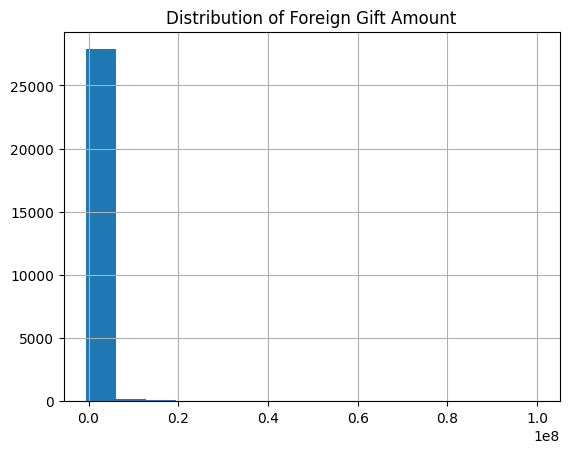

Findings: After plotting the histogram for "Foreign Gift Amount", it appears
that the graph is extremely right skewed, with the vasy majority of gifts
ranging in the lower range of price but a miniscule amount of the samples
reaching costs far beyond the average.

Thus, these rare but extremely large foreign gift amounts may impact
calculations substantially impact statistics such as the range and the mean.
Total gifts: 28221
       Gift Type  count
0       Contract  17274
1  Monetary Gift  10936
2    Real Estate     11
The proportion of Contract gifts to total gifts is 0.6120973742957372.
The proportion of Monetary gifts to total gifts is 0.3875128450444704.
The proportion of Real Estate gifts to total gifts is 0.00038978065979235324.


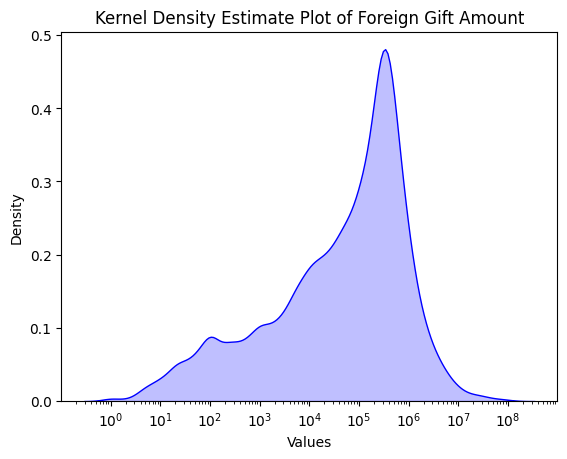

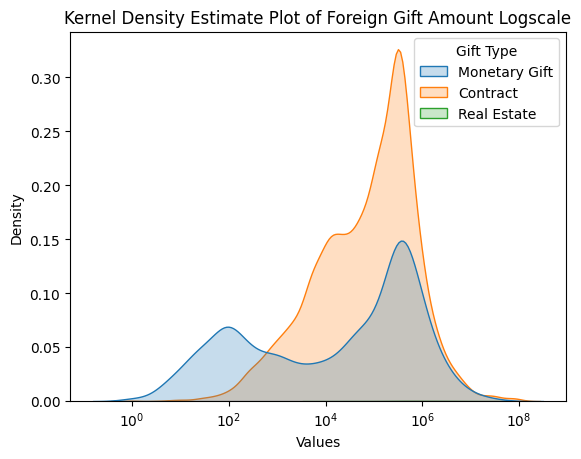

Based on the kernel density plots:

- Contract gifts are more concentrated around a relatively high log gift
amount as shown by the tall, orange peak

- Monetary gifts also have many samples that coincide with contract gifts
in the relatively high log gift amount, but is more evenly spread out and
variable across the board (i.e. some concentration in lower ends and some
in the higher ends; not as peaky as contract gifts)

- Real estate is practically non existent in the log graph; they may be
the values associated with the extreme large samples found earlier
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64
Country of Giftor
QATAR                   27

In [9]:
# Your Phase 2 solution to the problem goes here.
# IMPROVEMENTS MARKED [SUGGESTION]

# Question 2

# Q2.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # [SUGGESTION; moving import to the top and formatting it correctly]

df = pd.read_csv('A02-eda-and-visualization/data/ForeignGifts_edu.csv',)

# Q2.2

print(df['Foreign Gift Amount'].shape)

df.hist(column=['Foreign Gift Amount'], bins=15)
plt.title('Distribution of Foreign Gift Amount')
plt.show()

# [SUGGESTION; typo]

print("""Findings: After plotting the histogram for "Foreign Gift Amount", it appears
that the graph is extremely right skewed, with the vast majority of gifts
ranging in the lower range of price but a miniscule amount of the samples
reaching costs far beyond the average.

Thus, these rare but extremely large foreign gift amounts may impact
calculations substantially impact statistics such as the range and the mean.""")

# Q2.3

total_gift_type = len(df['Gift Type'].index)
print(f'Total gifts: {total_gift_type}')
counts_df = df['Gift Type'].value_counts().reset_index()
print(counts_df)

# [SUGGESTION; using .value_counts(normalize=True) instead of hardcoded proportions]

proportions = df['Gift Type'].value_counts(normalize=True)

# [SUGGESTION; fixing copy issue]
print(f'The proportion of Contract gifts to total gifts is {proportions["Contract"]}.')
print(f'The proportion of Monetary gifts to total gifts is {proportions["Monetary Gift"]}.')
print(f'The proportion of Real Estate gifts to total gifts is {proportions["Real Estate"]}.')

# Q2.4

import seaborn as sns

# [SUGGESTION; using Logscale for both + removing blue color in second KDE]
# Logscale Only

sns.kdeplot(df, x='Foreign Gift Amount', log_scale = True, fill=True, color="blue")


plt.title("Kernel Density Estimate Plot of Foreign Gift Amount")
plt.xlabel("Values")
plt.ylabel("Density")
plt.show()

# Logscale + Conditional
sns.kdeplot(df, x='Foreign Gift Amount', log_scale = True, fill=True, hue = 'Gift Type')

plt.title("Kernel Density Estimate Plot of Foreign Gift Amount Logscale")
plt.xlabel("Values")
plt.ylabel("Density")
plt.show()

print("""Based on the kernel density plots:

- Contract gifts are more concentrated around a relatively high log gift
amount as shown by the tall, orange peak

- Monetary gifts also have many samples that coincide with contract gifts
in the relatively high log gift amount, but is more evenly spread out and
variable across the board (i.e. some concentration in lower ends and some
in the higher ends; not as peaky as contract gifts)

- Real estate is practically non existent in the log graph; they may be
the values associated with the extreme large samples found earlier""")

# Q2.5

# Top 15 by number of gifts
print(df.groupby('Country of Giftor').size().sort_values(ascending=False).head(15)
)
# top 15 by amount given

print(df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
)
#Q2.6

# total Gift Money
print(df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15))

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main improvements with AI-assistance for this particular assignment were catching "silly" instances of errors or formatting. From a typo, copy and paste errors of print lines, and misreads of instructions that led to wrong graphics, the AI was able to point those mistakes out immediately and provide a specific course of action. It was also useful in verification of figures and logic; this was most apparent with the suggestions for Q2.3, which emphasized the consequence of hardcoded proportions and called to double check the total gift type count (in the case that there were na values not accounted for, which was an overlook in governance from me).

That being said, it was apparent that reading my submitted PDF (for Q1.2-Q1.4) was a hassle. It was unable to verify the effiacy of my proof for Q1.2 (which was correct), and it overlooked the fact that my response to Q1.4 had a function example that was NOT non-decreeasing. Thus, moving forward, it is probably best that I provide documents or pdf files sparingly to improve accuracy and reduce the risk of shoddy verification.

For final verification of this specific notebook, it was moreso checking that the output had no typos or readability issues rather than incorrect answers. The only three changes that needed to be verified for accuracy were the new proportions in Q2.3, the sum of the total gift type, and the kernel density plot in Q2.5. There was not much criticism on my responses to Question 1, so I simply looked over my proofs to double check mathematical consistency.